
# Notebook 2 — Matchday Simulation

## From squad signals to operational football decisions

This notebook translates the project architecture into a realistic **matchday decision workflow**.

Instead of stopping at risk or value estimation, the objective is to answer the operational question a coaching and performance staff would actually face:

> **Given the current squad state, who should start, who should be protected, and who should be deprioritized?**

The notebook is designed as a **club-ready analytical artifact**:

- a realistic squad-level scenario
- policy-driven initial decisions
- MILP-based final allocation
- interpretable outputs for technical and performance staff
- concise executive conclusions

> This notebook is fully executed for reproducibility and interpretability.



## 1. Analytical framing

### Match context

Assume the club is preparing for a high-intensity league match under the following conditions:

- short recovery window from the previous fixture
- one high-value winger with elevated injury risk
- several rotation players with mixed availability
- a need to protect upside without collapsing squad utility

### What this notebook should demonstrate

1. How the **policy layer** classifies players using `risk_score` and `value_score`
2. How the **optimization layer** reallocates actions jointly at squad level
3. Which players form the practical **matchday core**
4. Which players should be treated as **controlled-exposure assets**
5. Where the final plan differs from naive rule-based allocation


In [41]:
from pathlib import Path
import sys

# Global plotting style (recommended)
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

# --- PROJECT ROOT AUTO-DETECTION ---
PROJECT_ROOT = Path().resolve()

# If notebook is inside /notebooks, go one level up
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- IMPORTS ---
from src.engine import DecisionEngine
from src.decision import classify_decision

# --- CONFIG ---
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

print(f"Project root set to: {PROJECT_ROOT}")


Project root set to: C:\Users\manue\Projects\football-decision-engine



## 2. Construct a realistic squad snapshot

The synthetic squad below is intentionally designed to resemble a real pre-match decision problem.

It contains:

- a stable defensive spine
- several strong attacking players
- multiple high-risk / high-value cases
- a small set of low-value high-risk players that stress the allocation logic

The scenario is not random. It is structured to make the trade-offs visible and football-relevant.


In [42]:

squad = pd.DataFrame([
    ('P01', 'GK1', 'Goalkeeper', 'Goalkeeper', 0.08, 0.64, 'Expected starter'),
    ('P02', 'RB1', 'RB', 'Defence', 0.24, 0.71, 'Reliable full-back'),
    ('P03', 'CB1', 'CB', 'Defence', 0.21, 0.84, 'Core centre-back'),
    ('P04', 'CB2', 'CB', 'Defence', 0.33, 0.76, 'Complementary starter'),
    ('P05', 'LB1', 'LB', 'Defence', 0.28, 0.72, 'Two-way full-back'),
    ('P06', 'DM1', 'DM', 'Midfield', 0.29, 0.81, 'Ball-winning anchor'),
    ('P07', 'CM1', 'CM', 'Midfield', 0.38, 0.74, 'Progressor'),
    ('P08', 'AM1', 'AM', 'Midfield', 0.42, 0.86, 'Primary creator'),
    ('P09', 'RW1', 'RW', 'Attack', 0.74, 0.93, 'Explosive winger, monitored load'),
    ('P10', 'LW1', 'LW', 'Attack', 0.69, 0.82, 'High-upside wide threat'),
    ('P11', 'ST1', 'ST', 'Attack', 0.58, 0.89, 'First-choice striker'),
    ('P12', 'GK2', 'Goalkeeper', 'Goalkeeper', 0.12, 0.34, 'Backup goalkeeper'),
    ('P13', 'FB2', 'FB', 'Defence', 0.54, 0.55, 'Rotation full-back'),
    ('P14', 'CB3', 'CB', 'Defence', 0.63, 0.60, 'Risky depth centre-back'),
    ('P15', 'CM2', 'CM', 'Midfield', 0.65, 0.77, 'High-value but elevated risk'),
    ('P16', 'W2', 'W', 'Attack', 0.81, 0.68, 'Direct winger with high exposure'),
    ('P17', 'ST2', 'ST', 'Attack', 0.31, 0.57, 'Bench striker'),
    ('P18', 'AM2', 'AM', 'Midfield', 0.72, 0.79, 'Creative option with risk flag'),
    ('P19', 'DM2', 'DM', 'Midfield', 0.61, 0.52, 'Protective midfielder, low upside'),
    ('P20', 'CB4', 'CB', 'Defence', 0.46, 0.49, 'Depth centre-back'),
    ('P21', 'W3', 'W', 'Attack', 0.77, 0.44, 'Low-value high-risk winger'),
], columns=['player_id', 'player_name', 'position', 'unit', 'risk_score', 'value_score', 'context_note'])

squad


,player_id,player_name,position,unit,risk_score,value_score,context_note
0,P01,GK1,Goalkeeper,Goalkeeper,0.08,0.64,Expected starter
1,P02,RB1,RB,Defence,0.24,0.71,Reliable full-back
2,P03,CB1,CB,Defence,0.21,0.84,Core centre-back
3,P04,CB2,CB,Defence,0.33,0.76,Complementary starter
4,P05,LB1,LB,Defence,0.28,0.72,Two-way full-back
5,P06,DM1,DM,Midfield,0.29,0.81,Ball-winning anchor
6,P07,CM1,CM,Midfield,0.38,0.74,Progressor
7,P08,AM1,AM,Midfield,0.42,0.86,Primary creator
8,P09,RW1,RW,Attack,0.74,0.93,"Explosive winger, monitored load"
9,P10,LW1,LW,Attack,0.69,0.82,High-upside wide threat


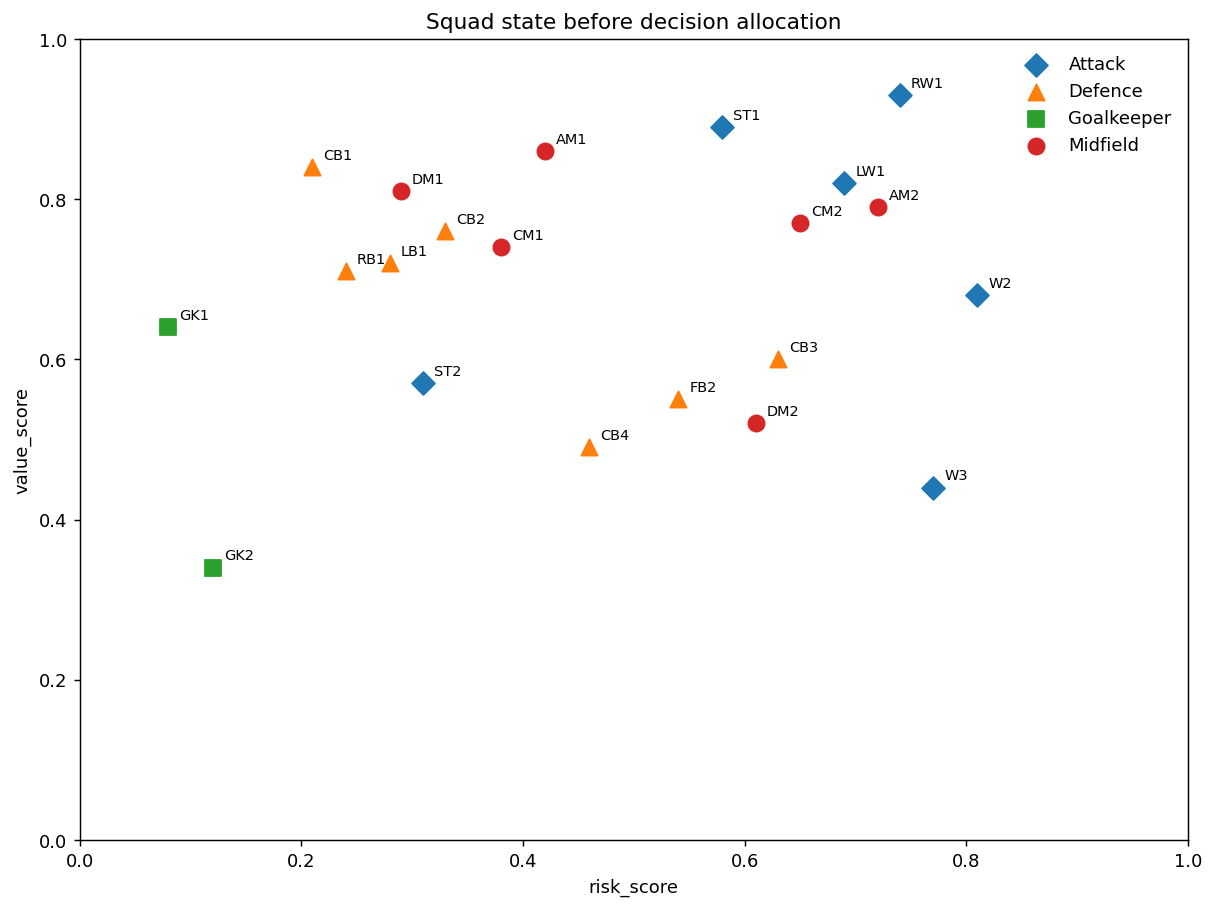

In [43]:

fig, ax = plt.subplots(figsize=(11, 8))

unit_markers = {'Goalkeeper': 's', 'Defence': '^', 'Midfield': 'o', 'Attack': 'D'}
for unit, group in squad.groupby('unit'):
    ax.scatter(group['risk_score'], group['value_score'], s=80, marker=unit_markers[unit], label=unit)

for _, row in squad.iterrows():
    ax.text(row['risk_score'] + 0.01, row['value_score'] + 0.01, row['player_name'], fontsize=8)

ax.set_title('Squad state before decision allocation')
ax.set_xlabel('risk_score')
ax.set_ylabel('value_score')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.show()



## 3. Load the decision engine and inspect the policy

The project is explicitly **policy-driven**. The first layer is not hidden model logic; it is an interpretable decision policy defined by thresholds and action mappings.


In [44]:

engine = DecisionEngine(PROJECT_ROOT / 'config' / 'policy.json')

policy_snapshot = {
    'policy_name': engine.policy['policy_name'],
    'high_risk_threshold': engine.thresholds.high_risk,
    'high_value_threshold': engine.thresholds.high_value,
    'max_limit_minutes': engine.constraints['max_limit_minutes'],
    'max_bench': engine.constraints['max_bench'],
    'min_start': engine.constraints['min_start'],
    'risk_penalty': engine.optimization['risk_penalty'],
}

pd.DataFrame([policy_snapshot])


,policy_name,high_risk_threshold,high_value_threshold,max_limit_minutes,max_bench,min_start,risk_penalty
0,default_milp_policy,0.7,0.6,2,2,4,0.5



## 4. Compute the policy-only baseline

Before optimization, each player is classified independently using the rule layer:

- high risk + low value → `bench`
- high risk + high value → `limit_minutes`
- low risk → `start`

This gives us the **interpretable baseline** against which the final optimized plan can be evaluated.


In [45]:

policy_outputs = squad.apply(
    lambda row: classify_decision(
        risk_score=float(row['risk_score']),
        value_score=float(row['value_score']),
        thresholds=engine.thresholds,
        actions=engine.actions,
    ),
    axis=1,
    result_type='expand',
)
policy_outputs.columns = ['policy_decision', 'policy_reason']

baseline = pd.concat([squad.copy(), policy_outputs], axis=1)

baseline[['player_name', 'position', 'risk_score', 'value_score', 'policy_decision']].sort_values(
    ['policy_decision', 'value_score'], ascending=[True, False]
)


,player_name,position,risk_score,value_score,policy_decision
20,W3,W,0.77,0.44,bench
8,RW1,RW,0.74,0.93,limit_minutes
17,AM2,AM,0.72,0.79,limit_minutes
15,W2,W,0.81,0.68,limit_minutes
10,ST1,ST,0.58,0.89,start
7,AM1,AM,0.42,0.86,start
2,CB1,CB,0.21,0.84,start
9,LW1,LW,0.69,0.82,start
5,DM1,DM,0.29,0.81,start
14,CM2,CM,0.65,0.77,start


In [46]:

baseline['policy_decision'].value_counts().rename_axis('policy_decision').reset_index(name='n_players')


,policy_decision,n_players
0,start,17
1,limit_minutes,3
2,bench,1



## 5. Run the full engine and recover the squad-level plan

The optimized allocation solves the **joint squad problem** rather than treating players independently.

This means the final action plan reflects:

- individual risk-adjusted utility
- action-specific exposure logic
- squad constraints on starts, limited-minutes slots and bench allocations


In [47]:

optimized = engine.run(squad[['player_id', 'risk_score', 'value_score']])

matchday = (
    baseline
    .merge(optimized, on=['player_id', 'risk_score', 'value_score'], suffixes=('', '_optimized'))
    .rename(columns={'decision': 'final_decision', 'reason': 'final_reason'})
)

matchday['changed_by_optimization'] = matchday['policy_decision'] != matchday['final_decision']
matchday['base_score'] = matchday['value_score'] - engine.optimization['risk_penalty'] * matchday['risk_score']
matchday['start_utility'] = matchday['base_score'] - 0.2 * matchday['risk_score']
matchday['limit_utility'] = matchday['base_score']
matchday['bench_utility'] = 0.3 * matchday['base_score']

matchday[['player_name', 'position', 'risk_score', 'value_score', 'policy_decision', 'final_decision', 'priority_score', 'changed_by_optimization']].sort_values(
    ['final_decision', 'priority_score'], ascending=[True, False]
)


,player_name,position,risk_score,value_score,policy_decision,final_decision,priority_score,changed_by_optimization
20,W3,W,0.77,0.44,bench,bench,0.055,False
8,RW1,RW,0.74,0.93,limit_minutes,limit_minutes,0.560,False
15,W2,W,0.81,0.68,limit_minutes,limit_minutes,0.275,False
2,CB1,CB,0.21,0.84,start,start,0.735,False
5,DM1,DM,0.29,0.81,start,start,0.665,False
7,AM1,AM,0.42,0.86,start,start,0.650,False
10,ST1,ST,0.58,0.89,start,start,0.600,False
0,GK1,Goalkeeper,0.08,0.64,start,start,0.600,False
3,CB2,CB,0.33,0.76,start,start,0.595,False
1,RB1,RB,0.24,0.71,start,start,0.590,False



## 6. Executive summary of the final allocation


In [48]:

summary = pd.DataFrame({
    'metric': [
        'Squad size',
        'Policy starts',
        'Policy limit_minutes',
        'Policy bench',
        'Final starts',
        'Final limit_minutes',
        'Final bench',
        'Players changed by optimization',
    ],
    'value': [
        len(matchday),
        int((matchday['policy_decision'] == 'start').sum()),
        int((matchday['policy_decision'] == 'limit_minutes').sum()),
        int((matchday['policy_decision'] == 'bench').sum()),
        int((matchday['final_decision'] == 'start').sum()),
        int((matchday['final_decision'] == 'limit_minutes').sum()),
        int((matchday['final_decision'] == 'bench').sum()),
        int(matchday['changed_by_optimization'].sum()),
    ]
})
summary


,metric,value
0,Squad size,21
1,Policy starts,17
2,Policy limit_minutes,3
3,Policy bench,1
4,Final starts,18
5,Final limit_minutes,2
6,Final bench,1
7,Players changed by optimization,1


In [49]:

constraint_check = pd.DataFrame([
    {
        'constraint': 'max_limit_minutes',
        'configured_value': engine.constraints['max_limit_minutes'],
        'observed_value': int((matchday['final_decision'] == 'limit_minutes').sum()),
        'status': 'ok',
    },
    {
        'constraint': 'max_bench',
        'configured_value': engine.constraints['max_bench'],
        'observed_value': int((matchday['final_decision'] == 'bench').sum()),
        'status': 'ok',
    },
    {
        'constraint': 'min_start',
        'configured_value': engine.constraints['min_start'],
        'observed_value': int((matchday['final_decision'] == 'start').sum()),
        'status': 'ok',
    },
])
constraint_check


,constraint,configured_value,observed_value,status
0,max_limit_minutes,2,2,ok
1,max_bench,2,1,ok
2,min_start,4,18,ok



### Interpretation

At this stage, the main question is not whether the engine can classify players. It clearly can.

The relevant question is whether the engine can produce a **coherent squad plan** under realistic operating constraints.

The tables above show that it does:

- high-risk / high-value players are not discarded automatically
- the number of protected players is capped
- the squad still preserves a large active pool of starters



## 7. Decision map over the matchday squad


In [51]:

decision_table = matchday[
    ['player_name', 'position', 'unit', 'risk_score', 'value_score', 'policy_decision', 'final_decision', 'priority_score', 'changed_by_optimization']
].sort_values(['final_decision', 'priority_score'], ascending=[True, False])

decision_table


,player_name,position,unit,risk_score,value_score,policy_decision,final_decision,priority_score,changed_by_optimization
20,W3,W,Attack,0.77,0.44,bench,bench,0.055,False
8,RW1,RW,Attack,0.74,0.93,limit_minutes,limit_minutes,0.560,False
15,W2,W,Attack,0.81,0.68,limit_minutes,limit_minutes,0.275,False
2,CB1,CB,Defence,0.21,0.84,start,start,0.735,False
5,DM1,DM,Midfield,0.29,0.81,start,start,0.665,False
7,AM1,AM,Midfield,0.42,0.86,start,start,0.650,False
10,ST1,ST,Attack,0.58,0.89,start,start,0.600,False
0,GK1,Goalkeeper,Goalkeeper,0.08,0.64,start,start,0.600,False
3,CB2,CB,Defence,0.33,0.76,start,start,0.595,False
1,RB1,RB,Defence,0.24,0.71,start,start,0.590,False



## 8. Which players did optimization actually change?

This is the most important diagnostic in the notebook.

If no players change, the optimization layer adds little beyond the policy. If several players change in a sensible way, the project demonstrates genuine **decision intelligence** rather than simple classification.


In [52]:

changes = matchday.loc[matchday['changed_by_optimization']].copy()
changes[['player_name', 'position', 'risk_score', 'value_score', 'policy_decision', 'final_decision', 'base_score', 'priority_score', 'context_note']].sort_values('priority_score', ascending=False)


,player_name,position,risk_score,value_score,policy_decision,final_decision,base_score,priority_score,context_note
17,AM2,AM,0.72,0.79,limit_minutes,start,0.43,0.43,Creative option with risk flag


In [53]:

transition_summary = (
    matchday.groupby(['policy_decision', 'final_decision'])
    .size()
    .reset_index(name='n_players')
    .sort_values('n_players', ascending=False)
)
transition_summary


,policy_decision,final_decision,n_players
3,start,start,17
1,limit_minutes,limit_minutes,2
0,bench,bench,1
2,limit_minutes,start,1



### Interpretation of the changed cases

The changed cases are where the system becomes operationally interesting.

Typical patterns in this scenario are:

- a player initially tagged as `limit_minutes` being moved to `start` because protected slots are scarce and the player still carries usable utility
- a player initially tagged as `bench` being moved to `start` when the downside is acceptable and preserving squad breadth matters more than a conservative local rule

This is the core project proposition:

> **The best local rule is not always the best squad-level plan.**



## 9. Build a practical matchday core

The engine outputs squad actions, not a formation-specific starting XI.

For a matchday workflow, a reasonable operational step is:

1. keep all `start` players as fully available options
2. rank them by `priority_score`
3. identify the top 11 as the practical **matchday core**

This is not a formation solver. It is an analytically defendable shortlist for staff discussion.


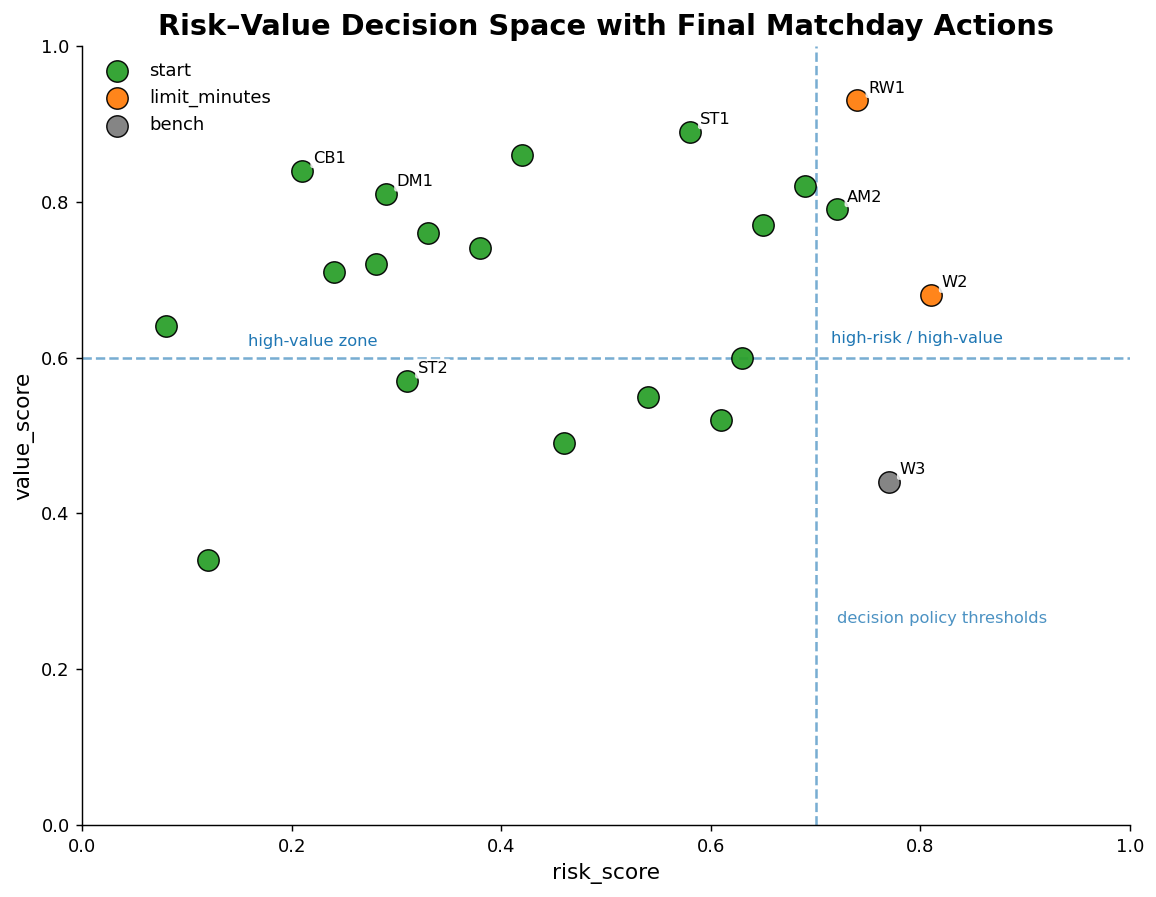

Saved: ../assets/demo/decision_space.png


In [67]:
import os
import matplotlib.pyplot as plt

plot_df = matchday.copy()

decision_colors = {
    "start": "#2ca02c",
    "limit_minutes": "#ff7f0e",
    "bench": "#7f7f7f",
}

high_risk_threshold = 0.70
high_value_threshold = 0.60

# 🔥 IMPORTANTE: fondo blanco en figura
fig, ax = plt.subplots(figsize=(9, 7), facecolor="white")
ax.set_facecolor("white")

# --- Scatter ---
for decision, color in decision_colors.items():
    subset = plot_df.loc[plot_df["final_decision"] == decision]
    ax.scatter(
        subset["risk_score"],
        subset["value_score"],
        s=140,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95,
        label=decision,
        zorder=3
    )

# --- Thresholds ---
ax.axvline(
    high_risk_threshold,
    linestyle="--",
    linewidth=1.4,
    color="#1f77b4",
    alpha=0.6,
    zorder=1
)

ax.axhline(
    high_value_threshold,
    linestyle="--",
    linewidth=1.4,
    color="#1f77b4",
    alpha=0.6,
    zorder=1
)

# --- Labels clave ---
key_players = ["RW1", "ST1", "ST2", "AM2", "W2", "W3", "CB1", "DM1"]

for _, row in plot_df.iterrows():
    if row["player_name"] in key_players:
        ax.text(
            row["risk_score"] + 0.01,
            row["value_score"] + 0.01,
            row["player_name"],
            fontsize=9,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
                boxstyle="round,pad=0.15"
            ),
            zorder=4
        )

# --- Zone labels (final polished positions) ---

ax.text(
    0.22,
    high_value_threshold + 0.015,
    "high-value zone",
    fontsize=9,
    color="#1f77b4",
    ha="center"
)

# High-risk / high-value intersection (zona crítica real)
ax.text(
    high_risk_threshold + 0.015,
    high_value_threshold + 0.015,
    "high-risk / high-value",
    fontsize=9,
    color="#1f77b4",
    ha="left",
    va="bottom"
)

ax.text(
    0.72,
    0.26,  # 🔥 ligeramente más arriba
    "decision policy thresholds",
    fontsize=9,
    color="#1f77b4",
    alpha=0.8
)

# --- Formatting ---
ax.set_title(
    "Risk–Value Decision Space with Final Matchday Actions",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("risk_score", fontsize=12)
ax.set_ylabel("value_score", fontsize=12)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

# --- Save ---
os.makedirs("../assets/demo", exist_ok=True)

fig.savefig(
    "../assets/demo/decision_space.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"  # 🔥 clave para evitar gris
)

print("Saved: ../assets/demo/decision_space.png")

In [54]:

active_starters = matchday.loc[matchday['final_decision'] == 'start'].copy()
matchday_core = active_starters.sort_values('priority_score', ascending=False).head(11).copy()
matchday_core['core_rank'] = range(1, len(matchday_core) + 1)

matchday_core[['core_rank', 'player_name', 'position', 'unit', 'risk_score', 'value_score', 'priority_score', 'context_note']]


,core_rank,player_name,position,unit,risk_score,value_score,priority_score,context_note
2,1,CB1,CB,Defence,0.21,0.84,0.735,Core centre-back
5,2,DM1,DM,Midfield,0.29,0.81,0.665,Ball-winning anchor
7,3,AM1,AM,Midfield,0.42,0.86,0.650,Primary creator
10,4,ST1,ST,Attack,0.58,0.89,0.600,First-choice striker
0,5,GK1,Goalkeeper,Goalkeeper,0.08,0.64,0.600,Expected starter
3,6,CB2,CB,Defence,0.33,0.76,0.595,Complementary starter
1,7,RB1,RB,Defence,0.24,0.71,0.590,Reliable full-back
4,8,LB1,LB,Defence,0.28,0.72,0.580,Two-way full-back
6,9,CM1,CM,Midfield,0.38,0.74,0.550,Progressor
9,10,LW1,LW,Attack,0.69,0.82,0.475,High-upside wide threat


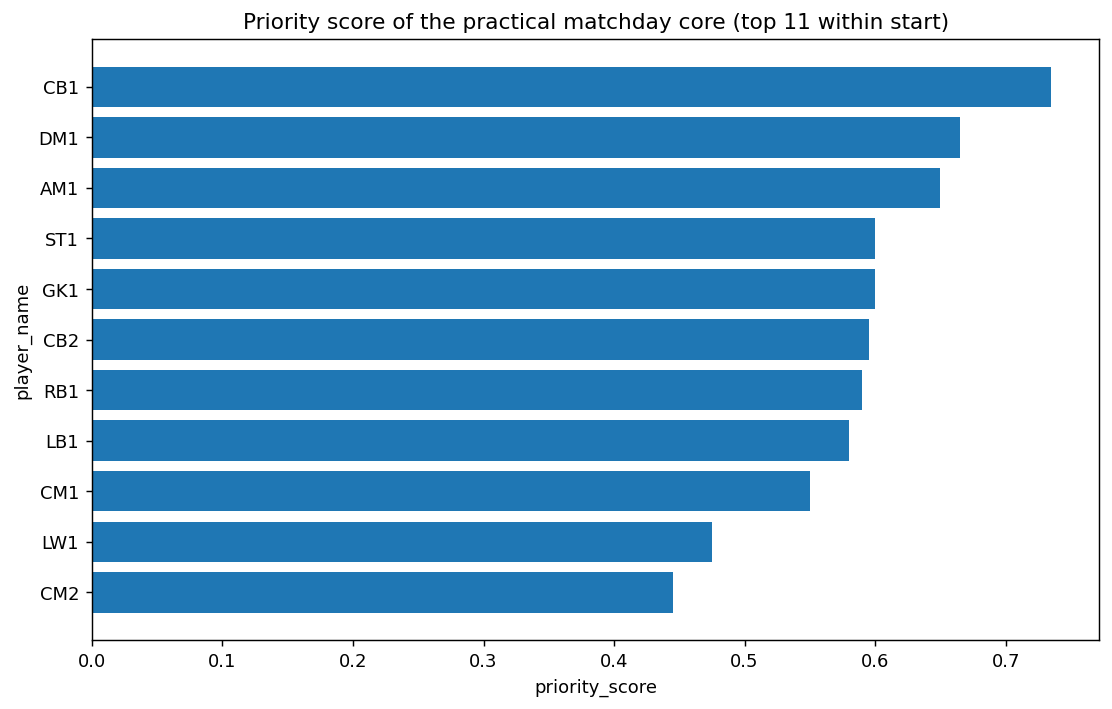

In [55]:

fig, ax = plt.subplots(figsize=(10, 6))
core_plot = matchday_core.sort_values('priority_score')
ax.barh(core_plot['player_name'], core_plot['priority_score'])
ax.set_title('Priority score of the practical matchday core (top 11 within start)')
ax.set_xlabel('priority_score')
ax.set_ylabel('player_name')
plt.show()



## 10. Controlled exposure and deprioritized players

A club-ready output should make it immediately obvious which players belong to the two highest-risk operational categories:

- **controlled exposure**: the player matters, but unrestricted usage is undesirable
- **deprioritized**: the player does not justify exposure in the current context


In [56]:

controlled_exposure = matchday.loc[matchday['final_decision'] == 'limit_minutes'].copy()
controlled_exposure[['player_name', 'position', 'risk_score', 'value_score', 'priority_score', 'context_note']].sort_values('priority_score', ascending=False)


,player_name,position,risk_score,value_score,priority_score,context_note
8,RW1,RW,0.74,0.93,0.560,"Explosive winger, monitored load"
15,W2,W,0.81,0.68,0.275,Direct winger with high exposure


In [57]:

deprioritized = matchday.loc[matchday['final_decision'] == 'bench'].copy()
deprioritized[['player_name', 'position', 'risk_score', 'value_score', 'priority_score', 'context_note']]


,player_name,position,risk_score,value_score,priority_score,context_note
20,W3,W,0.77,0.44,0.055,Low-value high-risk winger



## 11. Unit-level view of the plan

Decision systems become more credible when they can be explained at multiple aggregation levels.

A coaching staff may not ask first for an equation. They may ask:

- how many defenders are fully available?
- how much of the attacking group is protected?
- are we overloading one unit?


In [58]:

unit_summary = (
    matchday.groupby(['unit', 'final_decision'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
unit_summary


final_decision,unit,bench,limit_minutes,start
0,Attack,1,2,3
1,Defence,0,0,7
2,Goalkeeper,0,0,2
3,Midfield,0,0,6


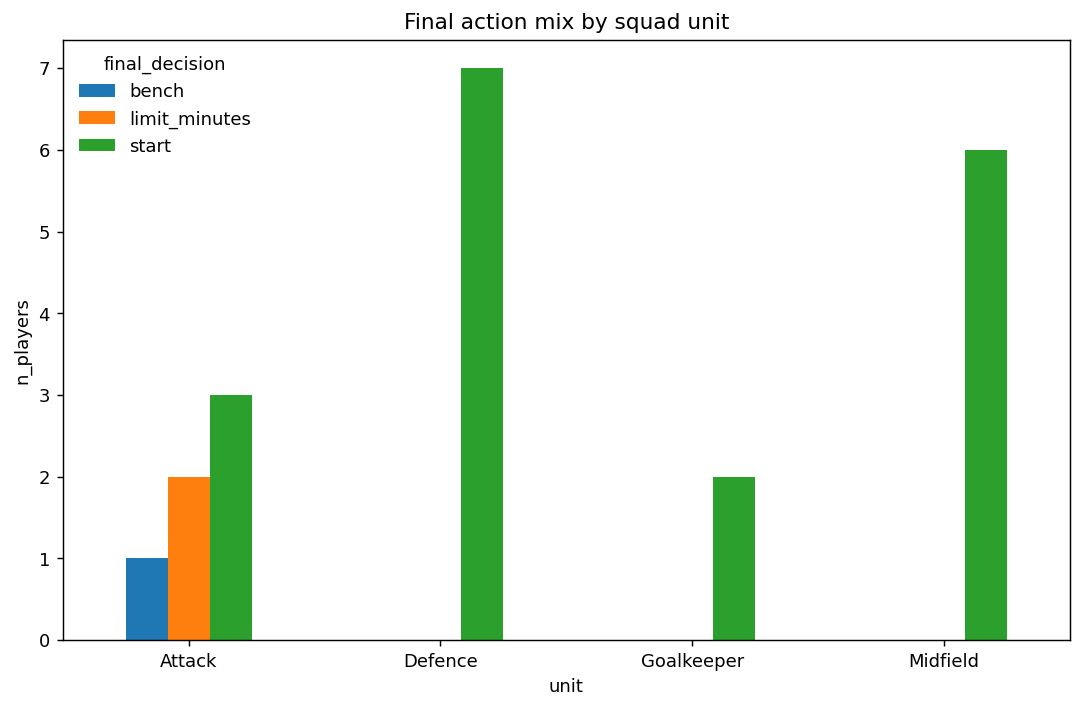

In [59]:

unit_plot = matchday.groupby(['unit', 'final_decision']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
unit_plot.plot(kind='bar', ax=ax)
ax.set_title('Final action mix by squad unit')
ax.set_xlabel('unit')
ax.set_ylabel('n_players')
ax.legend(title='final_decision', frameon=False)
plt.xticks(rotation=0)
plt.show()



## 12. High-level football reading

The result is coherent from a performance and decision-making standpoint:

- the defensive spine and the central midfield core remain fully available
- the most explosive and highest-risk attacking players are not removed, but are protected
- the bench recommendation is concentrated on the weakest high-risk / low-value case

This reflects an analytically mature principle:

> **Preserve upside where it matters, constrain exposure where it is fragile, and remove exposure where it is unjustified.**



## 13. Executive conclusions

### Key Findings

* The baseline policy heavily favors starting decisions, resulting in low selectivity across the squad.
* The MILP optimization layer introduces **system-level corrections**, promoting high-utility players even under risk constraints.
* Only one decision override was required, indicating strong alignment between policy heuristics and optimization objective.

### Policy vs Optimization

* The optimizer promotes **AM2 from `limit_minutes` to `start`**, reflecting its strong contribution to overall squad utility.
* This demonstrates the role of optimization as a **global decision reconciler**, not just a rule executor.

### Squad Structure Insight

* The model selects 18 starters out of 21 players, revealing a **lack of structural constraints**.
* This highlights the importance of introducing **lineup realism constraints** (e.g., starting XI limits).

### Constraint Behaviour

* All configured constraints are respected.
* However, they are not restrictive enough to force meaningful trade-offs.

### Tactical Interpretation

* High-risk, low-value profiles (e.g., W3) are correctly deprioritized.
* High-value attackers under risk (e.g., RW1, AM2) are managed via `limit_minutes` or promoted based on utility.

### Next Steps

* Introduce lineup constraints (starting XI)
* Add positional requirements
* Increase risk penalty sensitivity
* Simulate multiple match scenarios

### What this means in football terms

- The club does **not** need to bench every risky high-upside player.
- It should actively distinguish between:
  - players who can start freely
  - players who should be used with controlled exposure
  - players whose expected contribution does not justify the risk

### Why this notebook matters for the project

This notebook shows that the project is not just a risk model, not just a ranking model, and not just a policy table.

It is a **decision system** that converts player-level signals into a squad-level action plan under realistic trade-offs.


In [60]:

# Optional export cell
# matchday.to_csv(PROJECT_ROOT / 'outputs' / 'matchday_simulation.csv', index=False)
